<a href="https://colab.research.google.com/github/harishmuh/Deep-Learning_study/blob/main/Image_data_preprocessing_part_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Image preprocessing part IV**

---

## **Introduction**

This notebook explores fundamental image preprocessing techniques in computer vision, focusing on morphological operations. These operations are essential for modifying the shape and structure of objects within an image, often used for noise reduction, feature extraction, and image segmentation.

We will cover:

*   **Erosion**: A process that shrinks or thins objects in a binary image.
*   **Dilatation**: A process that expands or thickens objects in a binary image.
*   **Morphological Gradient**: The difference between the dilation and erosion of an image, useful for edge detection.
*   **Opening**: An erosion followed by a dilation, used to remove small objects and smooth object boundaries.
*   **Closing**: A dilation followed by an erosion, used to fill small holes and connect disconnected objects.

## **Erosion and Dilatation**

In [1]:
# Importing libraries
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import numpy as np
from google.colab.patches import cv2_imshow

In [2]:
# Attaching the first image

# Image link
url = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/familywb.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url) as f:
    img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
child_image = np.array(img)

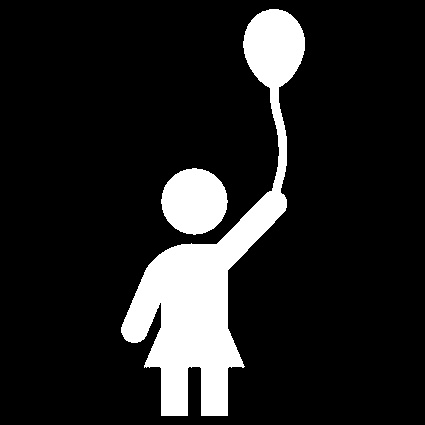

In [4]:
# Converting from BGR to RGB colour
child_image = cv2.cvtColor(child_image, cv2.COLOR_BGR2RGB)

# Displaying the image # RGB
cv2_imshow(child_image)

**Erosion operation**

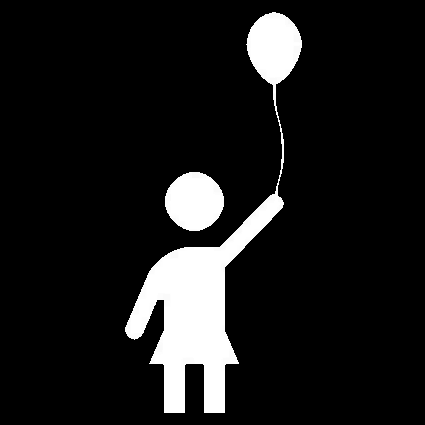

In [5]:
# Erosion operation

# Defining filter 7x7
filter7x7 = np.ones(shape=(7,7), dtype='uint8')

# Applying filter to the image
img_erode = cv2.erode(src=child_image, kernel=filter7x7, iterations=1)

# Displaying the image
cv2_imshow(img_erode)

We can see the result of the process as the child, line, and balloon become thinner in the eroded image.

**Dilatation operation**

We will use the same filter 7x7 for this dilatation process.

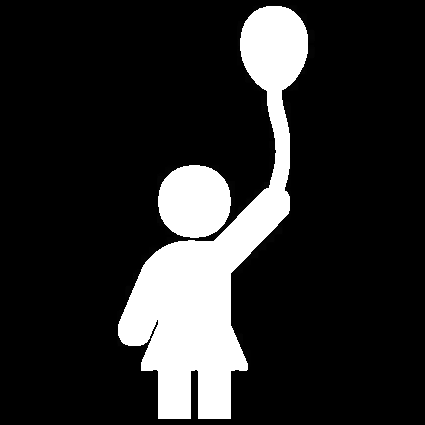

In [7]:
# Dilatation operation

# Applying filter to the image
img_dilate = cv2.dilate(src=child_image, kernel=filter7x7, iterations=1)

# Displaying the image
cv2_imshow(img_dilate)

In contrast to erotion operation, dilatation proceed the image of child, line, and balloon to be thicker than the original child image.

**Dilatation to the eroded image**

Now, we will try to dilate the eroded image.

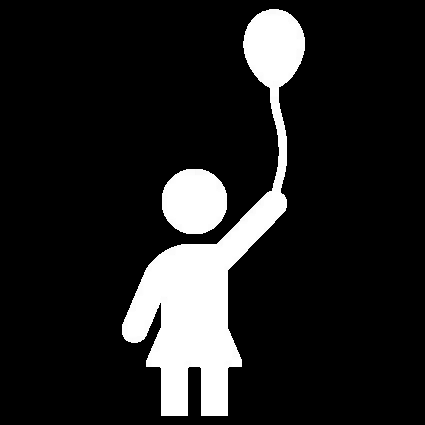

In [8]:
# Dilatation operation to the eroded image

# Applying filter to the image
img_dilate2 = cv2.dilate(src=img_erode, kernel=filter7x7, iterations=1)

# Displaying the image
cv2_imshow(img_dilate2)

The child, line, and balloon of the dilated image becomes thicker than the eroded image.

**Morphological gradient**

A morphological gradient is the difference between the dilation and the erosion of a given image. This tool can be used to detect edges by calculating contrast intensity in the close neighborhood of that pixel. It is useful for edge detection and segmentation applications.

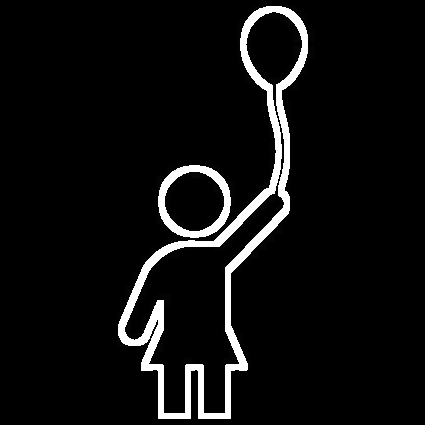

In [9]:
# Morphological gradient operation

# Applying morphological gradient
img_gradient = cv2.morphologyEx(child_image, cv2.MORPH_GRADIENT, filter7x7)

# Displaying the image
cv2_imshow(img_gradient)

## **Opening and Closing Operation**



Opening and Closing are dual operations used in Digital Image Processing for restoring an eroded image. The combination of Opening and Closing is generally used to clean up artifacts in the segmented image before using the image for digital analysis.

**Opening**

Opening is generally used to restore or recover the original image to the maximum possible extent. Opening is a process in which first erosion operation is performed and then dilation operation is performed.




Now, we will create a binary image with random noise. In this case, We will add noise to the background.

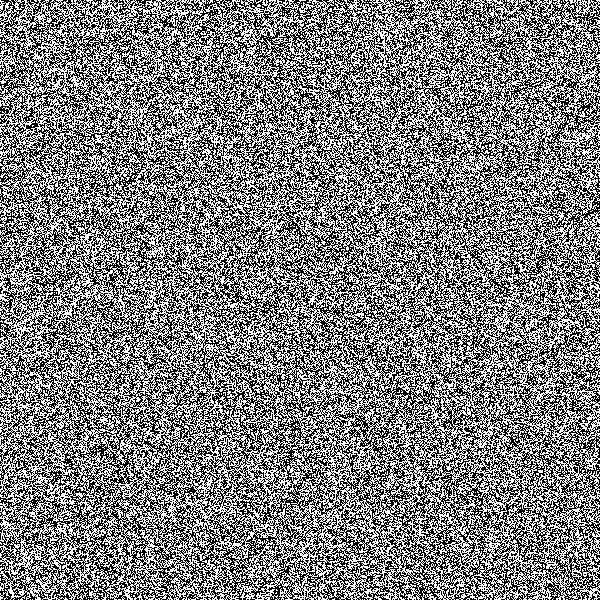

In [6]:
# Adding noise on the background

# importing libraries
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow

# Creating random noise
img_noise = np.random.randint(0, 2, (600,600), dtype=np.uint8)
img_noise = img_noise*255


# Displaying the image
cv2_imshow(img_noise)


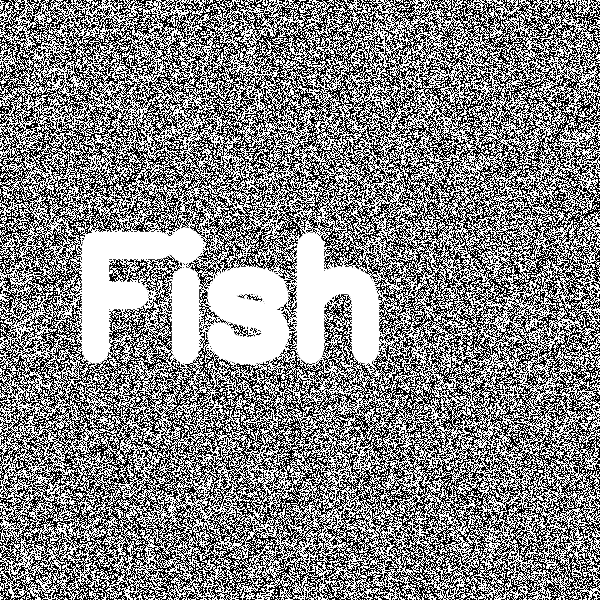

In [7]:
# Adding text to the image noise, for example 'Fish'
font = cv2.FONT_HERSHEY_SIMPLEX

cv2.putText(img=img_noise,
            text='Fish',
            org=(75,350),
            fontFace=font,
            fontScale=5,
            color=(255,255,255,),
            thickness=25,
            lineType=cv2.LINE_AA)

# Displaying the image
cv2_imshow(img_noise)

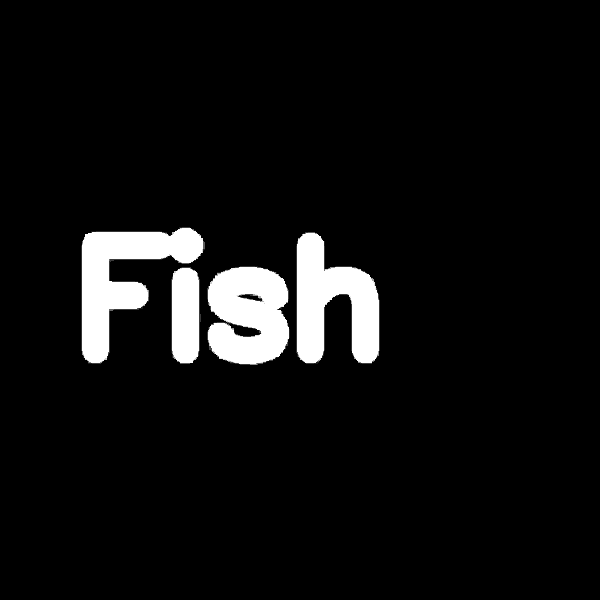

In [8]:
# Removing noise with filter(7x7)
filter7x7 = np.ones(shape=(7,7), dtype=np.uint8)
img_txt_clean = cv2.morphologyEx(img_noise,
                                 cv2.MORPH_OPEN,
                                 filter7x7)

# Displaying the image
cv2_imshow(img_txt_clean)


Now, we have removed the background noise

**Closing**

Closing is generally used to smoother the contour of the distorted image and fuse back the narrow breaks and long thin gulfs. Closing is also used for getting rid of the small holes of the obtained image. Closing is a process in which first dilation operation is performed and then erosion operation is performed.

Now we will also create random noise, but we place it on the front of the image.

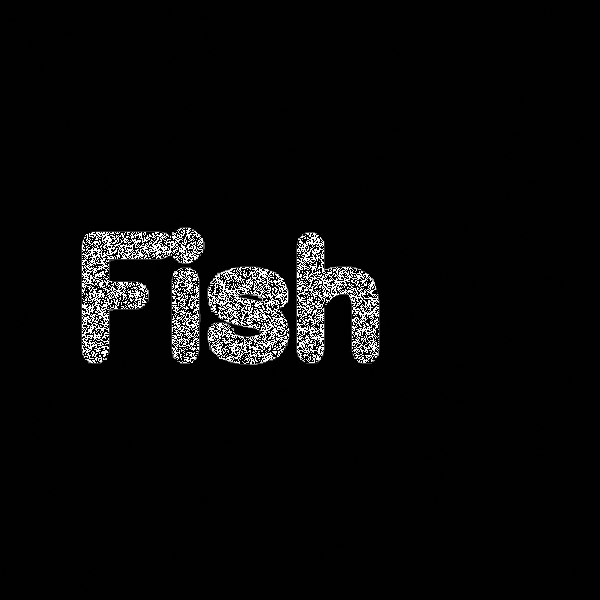

In [11]:
# Creating random noise
img_noise = np.random.randint(0, 2, (600,600), dtype=np.uint8)
img_noise = img_noise*255

img_txt_black_noise = img_txt_clean - img_noise

img_txt_black_noise[img_txt_black_noise==-255] = 0

# Displaying the image
cv2_imshow(img_txt_black_noise)

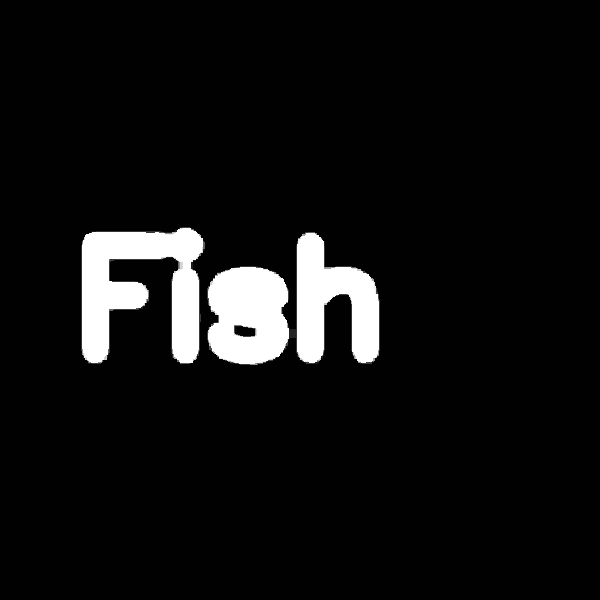

In [12]:
# Applying closing operation
img_clean = cv2.morphologyEx(img_txt_black_noise,
                             cv2.MORPH_CLOSE,
                             filter7x7)

# Displaying the image
cv2_imshow(img_clean)

Now we have removed the noise on the front of the image.

## **Conclusion**

In this notebook, we explored fundamental morphological operations in image processing: erosion, dilatation, morphological gradient, opening, and closing. We saw how these techniques can be applied to modify image features, remove noise, and prepare images for further analysis. Erosion shrinks objects, dilatation expands them, the morphological gradient highlights edges, opening removes small objects and smooths boundaries, and closing fills small holes and connects broken objects. These operations are crucial tools in computer vision for tasks such as segmentation, noise reduction, and object recognition.